##Lab 4 a

In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train classifier on full dataset
model = DecisionTreeClassifier()
model.fit(X, y)

# Predict class for new observation
observation = [[5, 4, 3, 2]]
prediction = model.predict(observation)
print(f"Predicted class: {iris.target_names[prediction][0]}")

# View predicted class probabilities
proba = model.predict_proba(observation)
print(f"Class probabilities: {proba}")

Predicted class: versicolor
Class probabilities: [[0. 1. 0.]]


##Lab 4 b

In [19]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# load iris dataset
iris = iris = load_iris()
X = iris.data
y = iris.target

# create Random Forest Classifier
clf = RandomForestClassifier(random_state=42)

# train the model
clf.fit(X, y)

# make a new observation and predict observation’s class
observation = [[5, 4, 3, 2]]
prediction = clf.predict(observation)

print("Predicted class:", prediction)
print("Predicted class name:", iris.target_names[prediction][0])


print(clf.predict_proba(observation))

Predicted class: [1]
Predicted class name: versicolor
[[0.03 0.54 0.43]]


   credit.policy             purpose  int.rate  installment  log.annual.inc  \
0              1  debt_consolidation    0.1189       829.10       11.350407   
1              1         credit_card    0.1071       228.22       11.082143   
2              1  debt_consolidation    0.1357       366.86       10.373491   
3              1  debt_consolidation    0.1008       162.34       11.350407   
4              1         credit_card    0.1426       102.92       11.299732   

     dti  fico  days.with.cr.line  revol.bal  revol.util  inq.last.6mths  \
0  19.48   737        5639.958333      28854        52.1               0   
1  14.29   707        2760.000000      33623        76.7               0   
2  11.63   682        4710.000000       3511        25.6               1   
3   8.10   712        2699.958333      33667        73.2               1   
4  14.97   667        4066.000000       4740        39.5               0   

   delinq.2yrs  pub.rec  not.fully.paid  
0            0        0   

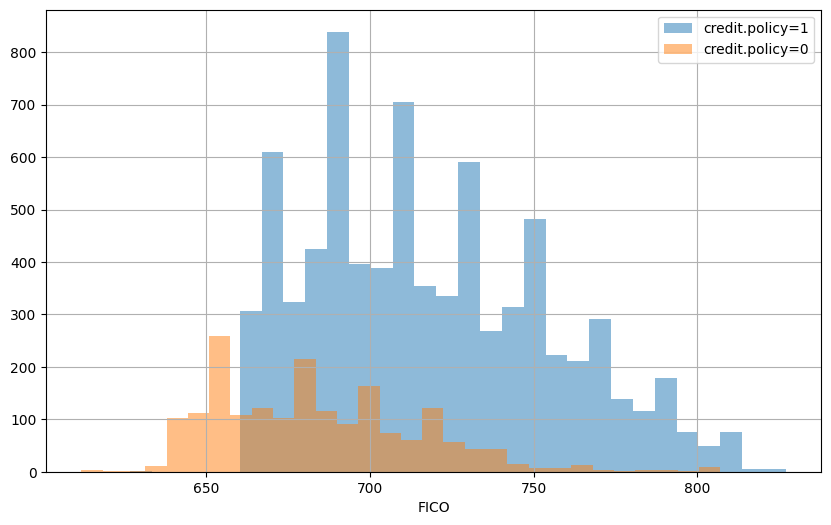

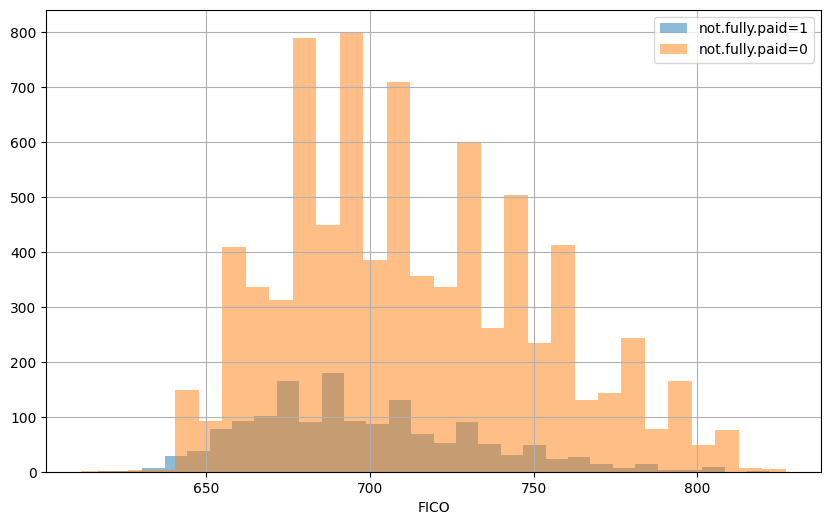

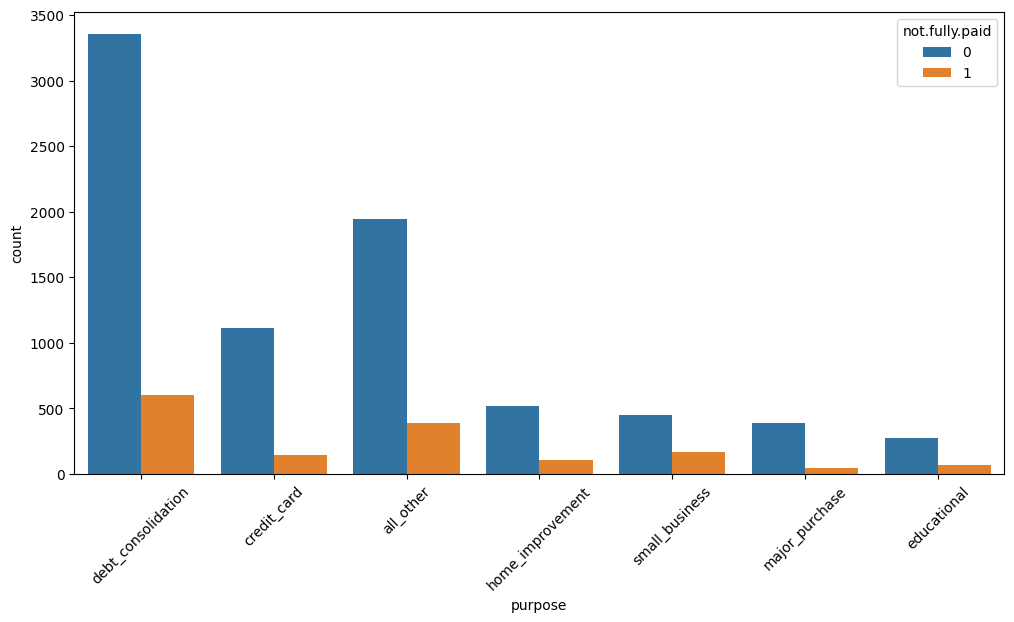

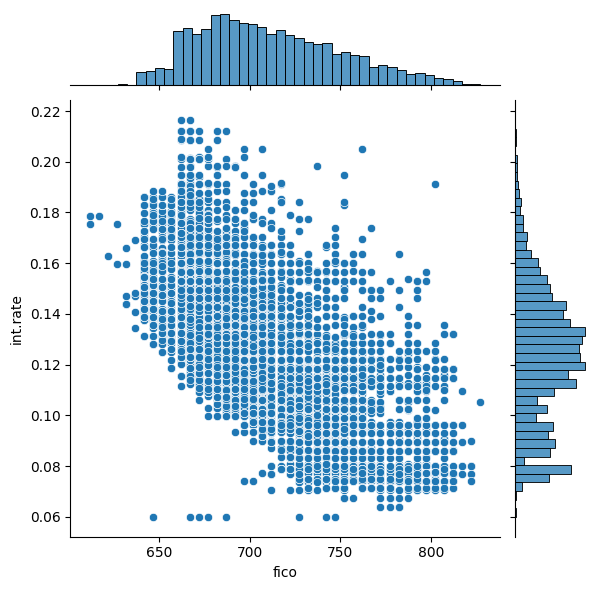

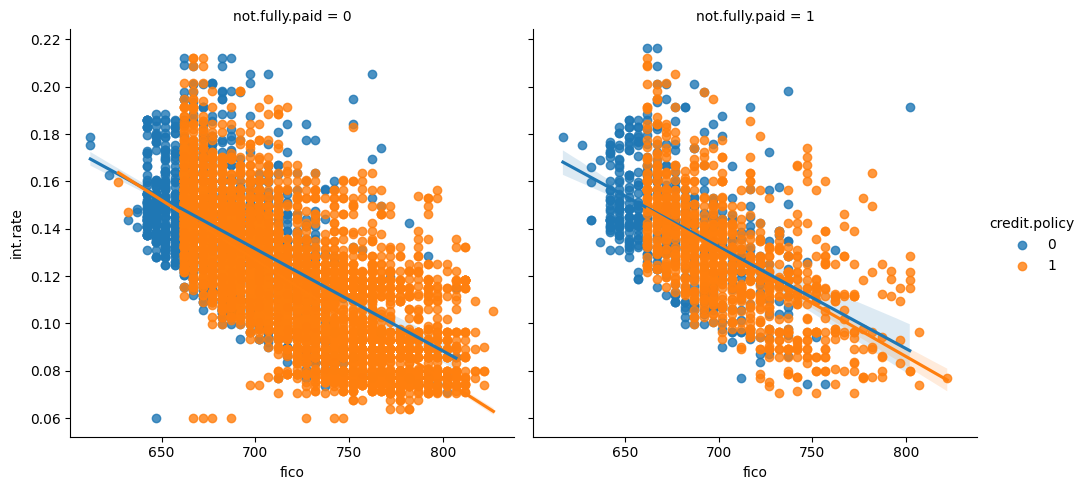

   credit.policy  int.rate  installment  log.annual.inc    dti  fico  \
0              1    0.1189       829.10       11.350407  19.48   737   
1              1    0.1071       228.22       11.082143  14.29   707   
2              1    0.1357       366.86       10.373491  11.63   682   
3              1    0.1008       162.34       11.350407   8.10   712   
4              1    0.1426       102.92       11.299732  14.97   667   

   days.with.cr.line  revol.bal  revol.util  inq.last.6mths  delinq.2yrs  \
0        5639.958333      28854        52.1               0            0   
1        2760.000000      33623        76.7               0            0   
2        4710.000000       3511        25.6               1            0   
3        2699.958333      33667        73.2               1            0   
4        4066.000000       4740        39.5               0            1   

   pub.rec  not.fully.paid  purpose_credit_card  purpose_debt_consolidation  \
0        0               0     

In [ ]:
# 1. Import the libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 2. Load the data and do a brief exploration of the data
loans = pd.read_csv("./data/loan_data(in).csv")

print(loans.head())
print(loans.info())
print(loans.describe())
print(loans.columns)

# 3. Exploratory Data Analysis

# histogram of FICO scores by credit policy
plt.figure(figsize=(10,6))
loans[loans['credit.policy']==1]['fico'].hist(bins=30, alpha=0.5, label='credit.policy=1')
loans[loans['credit.policy']==0]['fico'].hist(bins=30, alpha=0.5, label='credit.policy=0')
plt.legend()
plt.xlabel('FICO')

# histogram of FICO scores by not fully paid
plt.figure(figsize=(10,6))
loans[loans['not.fully.paid']==1]['fico'].hist(bins=30, alpha=0.5, label='not.fully.paid=1')
loans[loans['not.fully.paid']==0]['fico'].hist(bins=30, alpha=0.5, label='not.fully.paid=0')
plt.legend()
plt.xlabel('FICO')

# countplot of loan purpose by not fully paid
plt.figure(figsize=(12,6))
sns.countplot(x='purpose', hue='not.fully.paid', data=loans)
plt.xticks(rotation=45)

# jointplot between fico and interest rate
sns.jointplot(x='fico', y='int.rate', data=loans)

# lmplot
sns.lmplot(x='fico', y='int.rate', data=loans, hue='credit.policy', col='not.fully.paid')

plt.show()

# 4 & 5. Setting up the data
cat_feats = ['purpose']
final_data = pd.get_dummies(loans, columns=cat_feats, drop_first=True)

print(final_data.head())
print(final_data.info())

# 6. Train and Test Split
X = final_data.drop('not.fully.paid', axis=1)
y = final_data['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=101
)

# 7 & 8. Import DecisionTreeClassifier, create instance, fit model
dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

# 9. Predictions and evaluation of Decision Tree
dtree_predictions = dtree.predict(X_test)

print("Decision Tree Classification Report")
print(classification_report(y_test, dtree_predictions))

print("Decision Tree Confusion Matrix")
print(confusion_matrix(y_test, dtree_predictions))

# 10. Train the Random Forest model
rfc = RandomForestClassifier(n_estimators=200, random_state=101)
rfc.fit(X_train, y_train)

# 11. Predict the class of not.fully.paid for X_test
rfc_predictions = rfc.predict(X_test)
print("Predictions:")
print(rfc_predictions)
print(y_test.value_counts())
print(pd.Series(rfc_predictions).value_counts())

# 12. Classification report
print("Random Forest Classification Report")
print(classification_report(y_test, rfc_predictions))

# 13. Confusion Matrix
print("Random Forest Confusion Matrix")
print(confusion_matrix(y_test, rfc_predictions))



